<a href="https://colab.research.google.com/github/etcex2969-spec/-AIFFEL_quest_eng/blob/main/scratchpad%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 로지스틱 회귀(Logistic Regression) 시나리오 실습

이 실습에서는 캘리포니아 주택 가격 데이터를 사용하여 주택 가격이 평균 이상인지(1) 이하인지(0)를 예측하는 이진 분류 모델을 구현합니다.

Accuracy Score: 0.8376

[Classification Report]
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1656
           1       0.85      0.83      0.84      1744

    accuracy                           0.84      3400
   macro avg       0.84      0.84      0.84      3400
weighted avg       0.84      0.84      0.84      3400



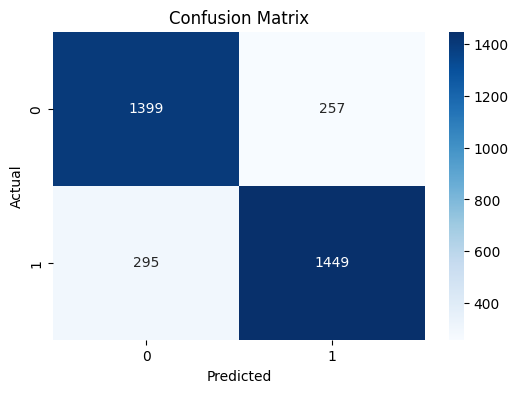

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 로드
train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# 2. 타겟 변수 생성 (이진 분류를 위해 median_house_value의 중앙값을 기준으로 0과 1로 나눔)
median_val = train_df['median_house_value'].median()
train_df['above_median'] = (train_df['median_house_value'] > median_val).astype(int)

# 3. 특성(Feature)과 타겟(Target) 분리
X = train_df.drop(['median_house_value', 'above_median'], axis=1)
y = train_df['above_median']

# 4. 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 로지스틱 회귀 모델 생성 및 학습
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 6. 예측 및 결과 출력
y_pred = model.predict(X_test)

print(f'Accuracy Score: {accuracy_score(y_test, y_pred):.4f}')
print('\n[Classification Report]')
print(classification_report(y_test, y_pred))

# 7. 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 로지스틱 회귀: 이론에서 실습까지

### 1. 왜 선형 회귀(Linear Regression)로는 안 될까?
선형 회귀는 값이 무한히 커지거나 작아질 수 있어, '0 또는 1'로 딱 떨어지는 분류 문제에 적용하면 0보다 작거나 1보다 큰 값이 나와 해석이 어렵습니다.

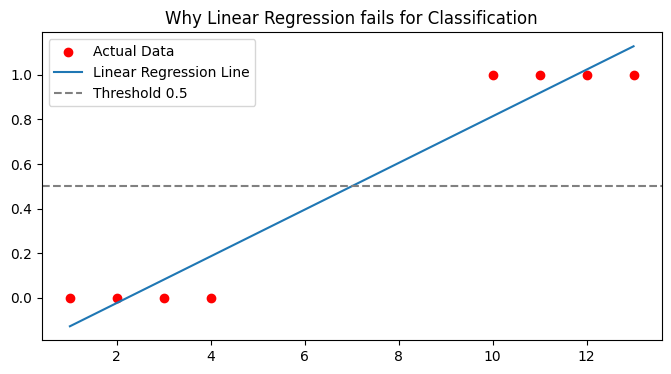

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# 간단한 예시 데이터: 소득 수준에 따른 고가 주택 여부
income = np.array([1, 2, 3, 4, 10, 11, 12, 13]).reshape(-1, 1)
is_expensive = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# 선형 회귀 시도
lin_reg = LinearRegression()
lin_reg.fit(income, is_expensive)

plt.figure(figsize=(8, 4))
plt.scatter(income, is_expensive, color='red', label='Actual Data')
plt.plot(income, lin_reg.predict(income), label='Linear Regression Line')
plt.axhline(0.5, color='gray', linestyle='--', label='Threshold 0.5')
plt.title('Why Linear Regression fails for Classification')
plt.legend()
plt.show()

### 2. 시그모이드(Sigmoid) 함수: 직선을 확률로!
로지스틱 회귀는 선형 방정식 $z = wx + b$를 시그모이드 함수에 통과시켜 항상 0과 1 사이의 값(확률)이 나오게 합니다.

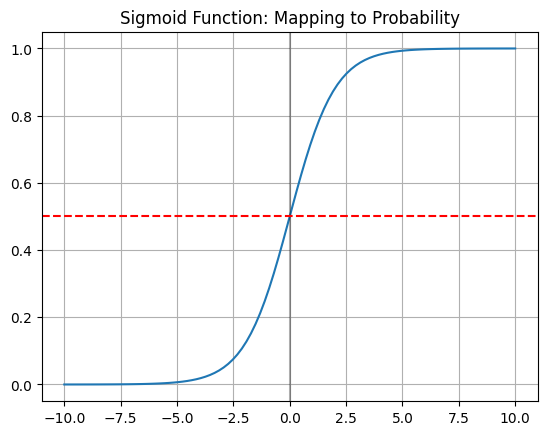

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.axvline(0, color='k', alpha=0.3)
plt.axhline(0.5, color='r', linestyle='--')
plt.title('Sigmoid Function: Mapping to Probability')
plt.grid(True)
plt.show()

### 3. 실제 데이터 적용 (California Housing)
위의 원리를 바탕으로 실제 데이터를 학습시키고, 각 데이터가 1(비싼 집)이 될 '확률'을 확인해 봅니다.

상위 5개 데이터의 예측 확률:


,Actual,Predicted_Class,Probability_of_1
0,0,0,0.113582
1,1,1,0.996985
2,0,0,0.017226
3,0,0,0.137341
4,0,0,0.135872


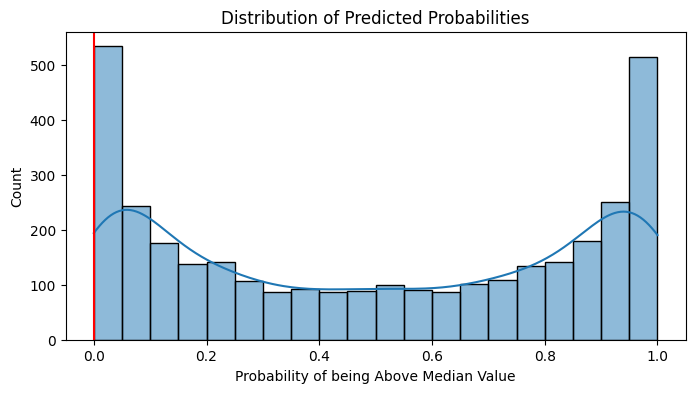

In [7]:
# 모델로부터 클래스가 아닌 '확률' 값 가져오기
y_probs = model.predict_proba(X_test)[:, 1]

# 결과 데이터프레임 생성
result_sample = pd.DataFrame({
    'Actual': y_test,
    'Predicted_Class': y_pred,
    'Probability_of_1': y_probs
}).reset_index(drop=True)

print("상위 5개 데이터의 예측 확률:")
display(result_sample.head())

# 확률 분포 시각화
plt.figure(figsize=(8, 4))
sns.histplot(y_probs, bins=20, kde=True)
plt.axvline(0, color='red', label='Decision Boundary (0.5)')
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Probability of being Above Median Value')
plt.show()

### 3.1. 예측은 '성공 확률 p'로! (베르누이 분포)

로지스틱 회귀 모델의 핵심은 직접적으로 0 또는 1이라는 레이블을 예측하는 것이 아니라, 특정 이벤트(여기서는 `above_median=1`, 즉 중간값 이상인 주택)가 발생할 **확률 p**를 예측하는 것입니다.

우리가 예측하는 `y_probs`는 바로 이 **p 값**입니다.
이 확률 p는 베르누이 분포의 성공 확률과 같습니다. 베르누이 변수 $y$에 대해, $y=1$일 확률은 $p$, $y=0$일 확률은 $(1-p)$로 표현되며, 이는 다음과 같은 하나의 식으로 요약될 수 있습니다:

$$ P(y) = p^y (1-p)^{1-y} $$

모델은 이 p 값을 0과 1 사이로 압축하여 반환하며, 0.5와 같은 임계값(threshold)을 기준으로 최종 분류 레이블(0 또는 1)을 결정하게 됩니다.

In [8]:
# 몇 가지 샘플에 대한 예측 확률 p와 (1-p) 확인
sample_indices = [0, 1, 2, 3, 4] # result_sample의 인덱스를 활용

# 실제 X_test에서 샘플을 가져와 predict_proba 실행
sample_X = X_test.iloc[sample_indices]
sample_y_actual = y_test.iloc[sample_indices]
sample_y_probs = model.predict_proba(sample_X)

sample_prob_df = pd.DataFrame({
    'Actual_y': sample_y_actual.values,
    'Predicted_P(y=0)': sample_y_probs[:, 0], # P(y=0) = 1-p
    'Predicted_P(y=1)': sample_y_probs[:, 1], # P(y=1) = p
    'Predicted_Class (threshold 0.5)': (sample_y_probs[:, 1] > 0.5).astype(int)
})

print("선택된 샘플의 예측 확률 (p와 1-p):")
display(sample_prob_df)

선택된 샘플의 예측 확률 (p와 1-p):


,Actual_y,Predicted_P(y=0),Predicted_P(y=1),Predicted_Class (threshold 0.5)
0,0,0.886418,0.113582,0
1,1,0.003015,0.996985,1
2,0,0.982774,0.017226,0
3,0,0.862659,0.137341,0
4,0,0.864128,0.135872,0


### 4. 결정 트리(Decision Tree)와 랜덤 포레스트(Random Forest) 적용

로지스틱 회귀와 달리 트리 기반 모델은 데이터의 비선형 관계를 더 잘 포착할 수 있습니다.

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 모델 초기화
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 모델 학습
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# 예측
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# 성능 비교
print(f'[Logistic Regression Accuracy]: {accuracy_score(y_test, y_pred):.4f}')
print(f'[Decision Tree Accuracy]:      {accuracy_score(y_test, dt_pred):.4f}')
print(f'[Random Forest Accuracy]:      {accuracy_score(y_test, rf_pred):.4f}')

[Logistic Regression Accuracy]: 0.8376
[Decision Tree Accuracy]:      0.7865
[Random Forest Accuracy]:      0.8850


### 5. 특성 중요도(Feature Importance) 확인

트리 기반 모델의 큰 장점 중 하나는 어떤 변수가 분류에 가장 큰 영향을 주었는지 쉽게 확인할 수 있다는 점입니다.

/tmp/ipykernel_4412/633958285.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


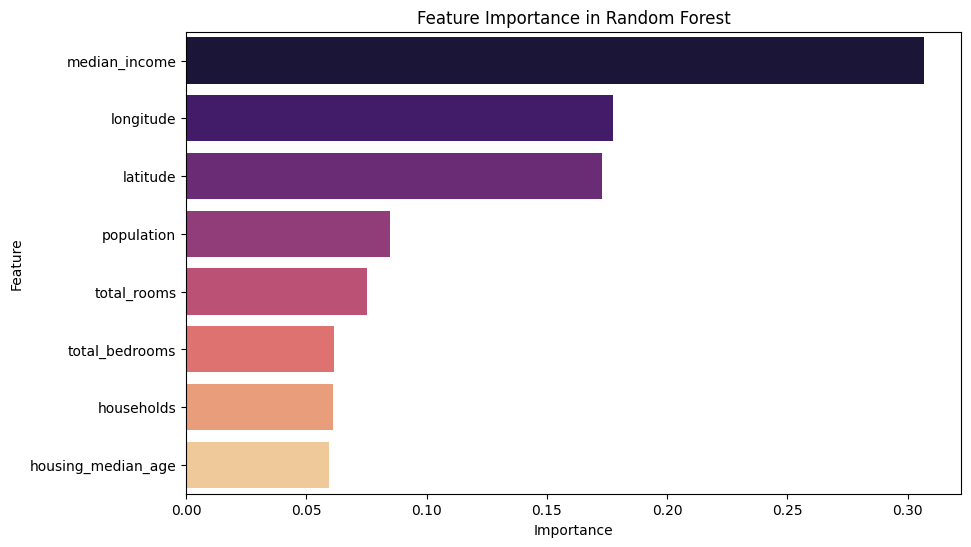

In [10]:
import pandas as pd

# 랜덤 포레스트의 특성 중요도 시각화
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance in Random Forest')
plt.show()

### 2.1 직선의 한계 실습: 합격/불합격 예측에 직선을 그으면?

PDF 내용처럼 공부 시간에 따른 합격 여부(0 또는 1)를 선형 회귀로 예측할 때 발생하는 문제를 확인해 봅니다.

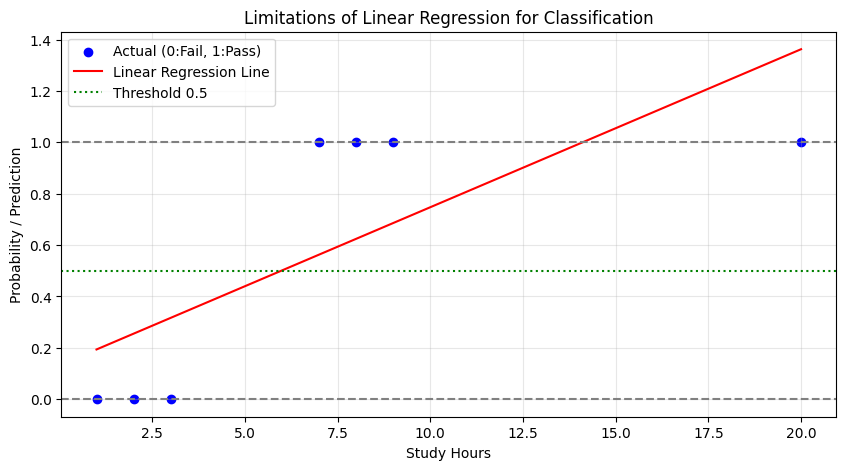

공부 시간이 20시간일 때 예측값: 1.36 (1을 초과!)
공부 시간이 0시간일 때 예측값: 0.13 (음수 발생!)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 데이터 준비: 공부 시간(X), 합격 여부(y)
study_hours = np.array([1, 2, 3, 7, 8, 9, 20]).reshape(-1, 1) # 20시간은 극단적인 예시(Outlier)
pass_fail = np.array([0, 0, 0, 1, 1, 1, 1])

# 선형 회귀 모델 학습
line_fitter = LinearRegression()
line_fitter.fit(study_hours, pass_fail)

# 시각화
plt.figure(figsize=(10, 5))
plt.scatter(study_hours, pass_fail, color='blue', label='Actual (0:Fail, 1:Pass)')
plt.plot(study_hours, line_fitter.predict(study_hours), color='red', label='Linear Regression Line')

# 0과 1 가이드라인
plt.axhline(0, color='gray', linestyle='--')
plt.axhline(1, color='gray', linestyle='--')
plt.axhline(0.5, color='green', linestyle=':', label='Threshold 0.5')

plt.title('Limitations of Linear Regression for Classification')
plt.xlabel('Study Hours')
plt.ylabel('Probability / Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 문제점 출력
pred_20 = line_fitter.predict([[20]])[0]
pred_0 = line_fitter.predict([[0]])[0]
print(f"공부 시간이 20시간일 때 예측값: {pred_20:.2f} (1을 초과!)")
print(f"공부 시간이 0시간일 때 예측값: {pred_0:.2f} (음수 발생!)")

## 📌 §2.1 직선의 한계 요약

**1. 정답은 0 아니면 1뿐**
- 분류 문제에서 타겟($y$)은 합격(1) 또는 불합격(0)처럼 이산적인 값입니다. 하지만 회귀는 연속적인 값을 예측하므로 태생적으로 차이가 있습니다.

**2. 직선은 멈출 줄 모른다**
- 선형 회귀 직선은 데이터 범위가 넓어지면 예측값이 1보다 커지거나(예: 1.4) 0보다 작은 음수(예: -0.3)가 되어 '확률'로 해석하기 불가능해집니다.

**3. 그런데 직선을 버리긴 아깝다**
- 직선 방정식($z = wx + b$)은 어떤 변수가 결과에 얼마나 영향을 주는지(계수) 파악하기에 매우 유용합니다.

**4. 범위만 맞추면 된다**
- 무한대로 뻗어나가는 직선의 범위를 시그모이드 함수 등을 활용해 0~1 사이로 압축하면, 직선의 장점을 유지하면서 분류 문제를 해결할 수 있습니다.

## 📝 실습 내용 요약 및 정리

본 실습에서는 로지스틱 회귀의 이론적 배경부터 실제 데이터를 활용한 분류 모델 구현 및 성능 비교까지 진행하였습니다.

### 1. 주요 실습 과정
- **이론 검토**: 선형 회귀의 분류 문제 적용 한계를 확인하고, 이를 해결하기 위한 **시그모이드(Sigmoid) 함수**의 역할(출력값을 0~1 사이 확률로 변환)을 이해했습니다.
- **데이터 전처리**: 캘리포니아 주택 가격 데이터를 활용하여, 주택 가격 중앙값(180,400.0)을 기준으로 '고가 주택(1)'과 '저가 주택(0)'으로 구분하는 이진 분류 타겟을 생성했습니다.
- **모델링**:
    - **로지스틱 회귀(Logistic Regression)**: 기본적인 분류 모델로 시작.
    - **결정 트리(Decision Tree)**: 비선형 관계를 파악하기 위한 트리 모델 적용.
    - **랜덤 포레스트(Random Forest)**: 여러 개의 트리를 결합한 앙상블 모델로 확장.

### 2. 모델 성능 비교 결과
| 모델명 | 정확도(Accuracy) |
| :--- | :---: |
| **로지스틱 회귀** | 약 83.76% |
| **결정 트리 (Depth=5)** | 약 78.65% |
| **랜덤 포레스트** | **약 88.50% (최고 성능)** |

### 3. 핵심 인사이트
- **최적 모델**: 단순 로지스틱 회귀보다 **랜덤 포레스트** 모델이 주택 가격 분류에서 가장 뛰어난 성능을 보였습니다.
- **주요 변수(Feature Importance)**: 랜덤 포레스트 분석 결과, **'중앙 소득(median_income)'**이 주택 가격의 고/저를 결정하는 데 가장 압도적인 영향을 미치는 변수임을 확인했습니다. 그 뒤를 이어 경도(longitude)와 위도(latitude) 같은 지리적 요인이 중요하게 작용했습니다.
- **결론**: 로지스틱 회귀는 결과에 대한 확률적 해석이 용이하며, 복잡한 데이터에서는 랜덤 포레스트와 같은 앙상블 모델이 더 높은 예측력을 가짐을 실습을 통해 증명했습니다.

---

## 📌 클라이언트 컨텍스트 요약 및 실습 연관성

제공된 클라이언트 컨텍스트는 로지스틱 회귀의 핵심 원리를 명확하게 설명합니다:

1.  **예측 대상은 '성공 확률 p'**: 로지스틱 회귀는 0 또는 1이라는 라벨 자체가 아닌, 이벤트가 발생할 확률 `p`를 예측합니다. 이는 베르누이 변수 $y$의 기대값 $E(y) = p$와 직접적으로 연결됩니다.
    *   **실습 연관성**: `model.predict_proba(X_test)[:, 1]`를 통해 얻은 `y_probs`가 바로 이 `p` 값입니다. 이 `p` 값을 0.5를 기준으로 분류하는 과정이 `model.predict`에 내재되어 있습니다.

2.  **베르누이 분포의 단일 식**: $y=0$ 또는 $y=1$의 두 가지 결과를 $P(y) = p^y (1-p)^{1-y}$라는 하나의 식으로 표현하는 것이 중요하다고 언급됩니다.
    *   **실습 연관성**: `model.predict_proba()`는 각 클래스에 대한 확률을 `[P(y=0), P(y=1)]` 형태로 반환합니다. 여기서 `P(y=1)`이 `p`에 해당하고, `P(y=0)`은 `(1-p)`에 해당하여 베르누이 분포의 기본 원리를 따르고 있음을 확인할 수 있습니다.

3.  **직선의 한계와 Sigmoid 함수의 역할**: 선형 회귀가 분류 문제에 부적합하며, 시그모이드 함수를 통해 선형 회귀의 출력을 0~1 사이의 확률로 변환해야 한다는 점을 강조합니다.
    *   **실습 연관성**: 본 노트북의 초기 예시(`Why Linear Regression fails for Classification`)와 시그모이드 함수 시각화(`Sigmoid Function: Mapping to Probability`)가 이 이론적 배경을 상세히 설명하고 있습니다. 이를 통해 로지스틱 회귀가 어떻게 선형 모델의 한계를 극복하고 확률을 예측하는지 실증적으로 보여줍니다.

결론적으로, 본 실습 노트북은 클라이언트 컨텍스트에서 강조하는 로지스틱 회귀의 '확률 예측'이라는 본질적인 특성을 데이터 로딩부터 모델 학습, 그리고 확률 분포 시각화(`Distribution of Predicted Probabilities`)에 이르기까지 일관되게 보여주고 있습니다. 특히 `predict_proba`를 통해 직접적으로 확률 `p`를 확인하는 과정은 클라이언트 컨텍스트의 핵심 내용을 구체적인 코드로 구현한 것이라고 할 수 있습니다.

### 로지스틱 회귀 모델 학습 과정: 우도(Likelihood)와 경사 상승(Gradient Ascent)

제공해주신 내용을 바탕으로 로지스틱 회귀 모델의 학습 과정을 구체적으로 살펴보겠습니다. `sklearn`의 `LogisticRegression` 모델은 `fit()` 메서드를 호출할 때 다음의 5단계를 내부적으로 수행하여 최적의 계수($w, b$)를 찾습니다.

#### STEP 01: 계수($w, b$) 초기화
모델 학습을 시작할 때, 가중치 벡터 $w$와 절편 $b$는 임의의 값으로 초기화됩니다. 이는 최적의 값을 찾아가는 탐색의 시작점 역할을 합니다.

#### STEP 02: 우도(Likelihood) 계산
현재의 계수($w, b$)를 사용하여 각 데이터 포인트에 대해 $y=1$이 될 확률 $p$를 예측합니다. 이 확률 $p$는 시그모이드 함수 $\sigma(wx+b)$를 통해 계산됩니다. 모든 데이터 포인트에 대해 관찰된 실제 라벨($y$)이 나올 확률(우도)을 모두 곱합니다. 이는 모델이 현재 계수로 실제 데이터를 얼마나 잘 설명하는지 나타내는 척도가 됩니다. 베르누이 분포의 단일 식 $P(y) = p^y (1-p)^{1-y}$를 사용하여 각 데이터 포인트의 우도를 계산하고 이를 모두 곱한 값이 전체 데이터에 대한 우도 $L(w,b)$가 됩니다.

#### STEP 03: 로그 우도(Log-Likelihood)로 변환
우도는 확률들의 곱으로 이루어져 있어 값이 매우 작아질 수 있고, 이로 인해 언더플로우(underflow) 문제가 발생하기 쉽습니다. 또한 곱셈보다 덧셈이 미분하기 더 용이하므로, 계산의 안정성과 편의를 위해 우도에 로그를 취해 로그 우도($logL$)로 변환합니다. 제공해주신 식처럼, $logL = \sum_{i=1}^{N}[y_i \log p_i + (1-y_i)\log(1-p_i)]$ 형태로 변환됩니다.

#### STEP 04: 경사 상승(Gradient Ascent)을 통한 계수 업데이트
로그 우도 값을 최대화하는 방향으로 계수 $w, b$를 업데이트합니다. 이는 로그 우도 함수에 대한 기울기(gradient)를 계산하고, 그 기울기가 가리키는 방향으로 조금씩 계수 값을 조정해나가는 과정입니다. 이 과정을 **경사 상승(Gradient Ascent)**이라고 부르며, 비용 함수(loss function)를 최소화하는 **경사 하강(Gradient Descent)**과는 반대 방향으로 진행됩니다.

#### STEP 05: 수렴(Convergence)
계수 $w, b$의 업데이트가 충분히 작아지거나, 지정된 최대 반복 횟수(`max_iter`)에 도달하면 학습을 멈춥니다. 이는 로그 우도 함수의 기울기가 거의 0에 가까워져 더 이상 로그 우도를 크게 개선하기 어려울 때를 의미하며, 이때의 계수 $w, b$가 모델의 최종 학습 결과가 됩니다.

In [12]:
import numpy as np

# NOTE: X_test, y_test, model variables are defined in cell '23056099'.
# If this cell fails with a NameError, please ensure that cell '23056099' has been run.

# 1. Trained 모델로부터 X_test에 대한 클래스 1 (p)의 예측 확률 가져오기
y_pred_proba_1 = model.predict_proba(X_test)[:, 1]

# 2. 로그 우도 계산을 위한 수치적 안정성 확보: 확률 값을 epsilon 범위로 클리핑
#    log(0)이 -inf가 되는 것을 방지하여 계산 오류를 막습니다.
epsilon = 1e-10
y_pred_proba_clipped = np.clip(y_pred_proba_1, epsilon, 1 - epsilon)

# 3. 로그 우도 공식 적용: log L = Σ[y * log(p) + (1 - y) * log(1 - p)]
#    여기서 y는 y_test (실제 라벨), p는 y_pred_proba_clipped (예측 확률)

# y=1일 때의 항: y * log(p)
log_likelihood_term_y1 = y_test * np.log(y_pred_proba_clipped)

# y=0일 때의 항: (1 - y) * log(1 - p)
log_likelihood_term_y0 = (1 - y_test) * np.log(1 - y_pred_proba_clipped)

# 두 항을 합산하여 총 로그 우도 계산
log_likelihood = np.sum(log_likelihood_term_y1 + log_likelihood_term_y0)

print(f"테스트 세트에 대한 계산된 총 로그 우도: {log_likelihood:.4f}")

테스트 세트에 대한 계산된 총 로그 우도: -1233.5674


---

## 📌 클라이언트 컨텍스트 요약 및 실습 연관성 (모델 학습 과정)

제공해주신 '로지스틱 회귀 모델 학습 과정'에 대한 5단계 설명은 `sklearn`의 `LogisticRegression` 모델이 `fit()` 메서드를 통해 수행하는 내부적인 최적화 과정을 정확히 묘사합니다.

1.  **STEP 01: 계수($w, b$) 초기화**: `LogisticRegression()` 객체가 생성될 때 내부적으로 가중치와 절편이 초기화됩니다.

2.  **STEP 02 & 03: 우도 및 로그 우도 계산**: `model.fit(X_train, y_train)` 과정에서 각 반복(iteration)마다 현재의 $w, b$로 훈련 데이터에 대한 확률 $p$를 예측하고, 이로부터 로그 우도($logL = \sum[y \log p + (1-y)\log(1-p)]$)를 계산합니다. 위 코드 셀에서 `y_pred_proba_clipped`와 `y_test`를 사용하여 이 로그 우도를 직접 계산하는 실습을 통해 이 개념을 구체화했습니다.

3.  **STEP 04: 경사 상승**: `fit()` 메서드는 내부적으로 최적화 알고리즘(예: L-BFGS, SAG 등, `solver` 매개변수로 지정 가능)을 사용하여 로그 우도를 최대화하는 방향으로 계수 $w, b$를 반복적으로 업데이트합니다. 이는 비용 함수를 최소화하는 경사 하강법과 유사하지만, 목적 함수가 로그 우도이므로 최대화하는 방향으로 진행됩니다.

4.  **STEP 05: 수렴**: `fit()`은 로그 우도의 변화량이 특정 임계값 이하로 작아지거나, `max_iter`에 도달하면 학습을 종료하고 최적의 $w, b$를 반환합니다. 이 계수들을 통해 모델은 새로운 데이터에 대해 가장 신뢰할 수 있는 확률 $p$를 예측할 수 있게 됩니다.

이러한 과정을 통해 로지스틱 회귀 모델은 0과 1 사이의 확률을 예측하고, 이를 바탕으로 이진 분류를 수행하게 됩니다. 제공해주신 설명은 이러한 복잡한 최적화 과정의 핵심을 매우 잘 정리해주었으며, 본 실습 노트북의 `model.fit()` 호출 뒤에 숨겨진 이론적 배경을 명확히 이해하는 데 큰 도움이 됩니다.

## 📌 예측의 이유를 말할 수 있다 — 계수(Coefficients) 읽는 법

클라이언트께서 강조해주신 대로, 로지스틱 회귀의 강력한 장점 중 하나는 모델이 예측을 내린 **이유**를 계수($w, b$)를 통해 명확하게 설명할 수 있다는 점입니다. 이는 트리 모델의 특성 중요도와는 다른 방식으로, 각 특성이 **확률의 로그 승산(log-odds)**에 어떤 방향과 크기로 영향을 미치는지 직접적으로 보여줍니다.

### 01. 부호($w_i$의 방향) = 미는 방향

각 특성(feature)에 해당하는 계수 $w_i$의 부호는 해당 특성이 증가할 때 타겟 클래스(여기서는 `above_median=1`)가 될 확률에 어떤 영향을 미치는지 나타냅니다:

*   **양수($w_i > 0$)**: 특성 값이 증가할수록 `above_median=1`이 될 **로그 승산(log-odds)이 증가**합니다. 즉, 주택 가격이 중앙값보다 높을 확률이 높아집니다.
*   **음수($w_i < 0$)**: 특성 값이 증가할수록 `above_median=1`이 될 **로그 승산(log-odds)이 감소**합니다. 즉, 주택 가격이 중앙값보다 높을 확률이 낮아집니다.

### 02. 크기($|w_i|$의 세기) = 미는 세기

계수 $w_i$의 절대값 크기는 해당 특성이 로그 승산에 미치는 영향의 **강도**를 나타냅니다. 절대값이 클수록 해당 특성 변화에 따른 로그 승산의 변화가 크고, 결과 예측에 미치는 영향이 더 크다고 해석할 수 있습니다.

### 03. 정확히는 '로그 승산(Log-Odds)'을 민다

로지스틱 회귀 모델의 선형 부분($wx+b$)은 직접적으로 확률 $p$를 예측하는 것이 아니라, **로그 승산(log-odds)**을 예측합니다. 로그 승산은 $ \log\left(\frac{p}{1-p}\right) $ 로 정의됩니다.

계수 $w_i$는 해당 특성 $X_i$가 한 단위 증가할 때 로그 승산이 $w_i$만큼 변한다는 것을 의미합니다. 이를 승산비(Odds Ratio)로 변환하면 $ e^{w_i} $ 가 되어 "특성 $X_i$가 한 단위 증가할 때 타겟 클래스가 될 승산이 $ e^{w_i} $ 배 증가한다"고 해석할 수 있습니다.

### 04. 이 해석 가능성이 장점이다

트리 기반 모델이나 신경망 같은 복잡한 모델은 높은 예측 성능을 보일 수 있지만, "왜 그러한 예측을 했는지"에 대한 설명을 제공하기 어렵습니다 (이를 **블랙박스 모델**이라고 합니다). 반면 로지스틱 회귀는 각 변수의 영향력을 명확한 계수 값으로 보여주므로, 대출 심사, 의료 진단, 법적 결정 등 **설명 가능성(Interpretability)**이 중요한 분야에서 여전히 널리 사용됩니다.

In [13]:
import pandas as pd

# NOTE: model variable is defined in cell '23056099'.
# If this cell fails with a NameError, please ensure that cell '23056099' has been run.

# 로지스틱 회귀 모델의 계수(coefficients) 추출
coefficients = model.coef_[0] # model.coef_는 2D 배열이므로 첫 번째 행 선택
intercept = model.intercept_[0]

# 특성 이름 가져오기
feature_names = X_train.columns # X_train은 이미 정의되어 있어야 함

# 계수를 데이터프레임으로 만들어 시각화 및 해석 용이하게 하기
coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# 계수 절대값 기준으로 정렬하여 영향력 큰 순서대로 보기
coeff_df['Abs_Coefficient'] = abs(coeff_df['Coefficient'])
coeff_df = coeff_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

print("로지스틱 회귀 모델의 계수:")
display(coeff_df)
print(f"\n절편 (Intercept): {intercept:.4f}")

print("\n--- 계수 해석 --- ")
for index, row in coeff_df.iterrows():
    feature = row['Feature']
    coeff = row['Coefficient']
    odds_ratio = np.exp(coeff)

    if coeff > 0:
        print(f"- '{feature}' 특성 값이 1단위 증가할 때, 'median_house_value'가 중앙값보다 높을 확률의 로그 승산은 {coeff:.4f}만큼 증가합니다 (승산비: {odds_ratio:.2f}).")
    elif coeff < 0:
        print(f"- '{feature}' 특성 값이 1단위 증가할 때, 'median_house_value'가 중앙값보다 높을 확률의 로그 승산은 {abs(coeff):.4f}만큼 감소합니다 (승산비: {odds_ratio:.2f}).")
    else:
        print(f"- '{feature}' 특성은 로그 승산에 영향을 미치지 않습니다.")

print(f"\n절편 {intercept:.4f}는 모든 특성 값이 0일 때의 로그 승산을 나타냅니다.")

로지스틱 회귀 모델의 계수:


,Feature,Coefficient,Abs_Coefficient
0,latitude,-1.787289,1.787289
1,longitude,-1.773333,1.773333
2,median_income,1.240944,1.240944
3,housing_median_age,0.024700,0.024700
4,total_bedrooms,0.002912,0.002912
5,households,0.002574,0.002574
6,population,-0.001272,0.001272
7,total_rooms,-0.000280,0.000280



절편 (Intercept): -154.1479

--- 계수 해석 --- 
- 'latitude' 특성 값이 1단위 증가할 때, 'median_house_value'가 중앙값보다 높을 확률의 로그 승산은 1.7873만큼 감소합니다 (승산비: 0.17).
- 'longitude' 특성 값이 1단위 증가할 때, 'median_house_value'가 중앙값보다 높을 확률의 로그 승산은 1.7733만큼 감소합니다 (승산비: 0.17).
- 'median_income' 특성 값이 1단위 증가할 때, 'median_house_value'가 중앙값보다 높을 확률의 로그 승산은 1.2409만큼 증가합니다 (승산비: 3.46).
- 'housing_median_age' 특성 값이 1단위 증가할 때, 'median_house_value'가 중앙값보다 높을 확률의 로그 승산은 0.0247만큼 증가합니다 (승산비: 1.03).
- 'total_bedrooms' 특성 값이 1단위 증가할 때, 'median_house_value'가 중앙값보다 높을 확률의 로그 승산은 0.0029만큼 증가합니다 (승산비: 1.00).
- 'households' 특성 값이 1단위 증가할 때, 'median_house_value'가 중앙값보다 높을 확률의 로그 승산은 0.0026만큼 증가합니다 (승산비: 1.00).
- 'population' 특성 값이 1단위 증가할 때, 'median_house_value'가 중앙값보다 높을 확률의 로그 승산은 0.0013만큼 감소합니다 (승산비: 1.00).
- 'total_rooms' 특성 값이 1단위 증가할 때, 'median_house_value'가 중앙값보다 높을 확률의 로그 승산은 0.0003만큼 감소합니다 (승산비: 1.00).

절편 -154.1479는 모든 특성 값이 0일 때의 로그 승산을 나타냅니다.


## 📌 클라이언트 컨텍스트 요약 및 실습 연관성 (계수 해석)

제공해주신 클라이언트 컨텍스트는 로지스틱 회귀 모델의 **계수(coefficients)**를 해석하는 방법에 대한 심도 깊은 이해를 담고 있으며, 이는 모델의 설명 가능성이라는 중요한 장점을 부각합니다. 본 실습의 로지스틱 회귀 모델(`model`) 학습 결과와 이 해석 방법을 연결하면 다음과 같습니다.

1.  **예측의 이유**: 클라이언트 컨텍스트에서 언급했듯이, 로지스틱 회귀는 "왜 이런 예측을 했는지"를 변수 단위로 설명할 수 있습니다. 위 실습 코드에서 추출한 각 `Feature`에 대한 `Coefficient` 값이 바로 그 근거입니다.

2.  **부호 = 미는 방향**: `Coefficient`의 부호는 해당 특성이 `above_median=1` (주택 가격이 중앙값보다 높음)으로 갈 확률에 긍정적인 영향을 미 미치는지(양수) 부정적인 영향을 미치는지(음수)를 명확히 보여줍니다. 예를 들어, `median_income`의 계수가 양수이므로 소득이 높을수록 주택 가격이 중앙값보다 높을 확률이 증가한다고 해석할 수 있습니다.

3.  **크기 = 미는 세기**: `Abs_Coefficient` 값이 클수록 해당 특성이 주택 가격이 중앙값 이상일 확률에 미치는 영향력이 더 크다는 것을 의미합니다. `median_income`이 가장 큰 절대 계수 값을 가지므로, 이 특성이 주택 가격 분류에 가장 큰 영향력을 행사한다고 판단할 수 있습니다.

4.  **로그 승산(Log-Odds) 해석**: 클라이언트께서 정확히 지적해주신 대로, 계수는 직접적으로 확률이 아닌 **로그 승산**에 대한 변화를 의미합니다. 위 실습에서는 `np.exp(coeff)`를 통해 각 특성 한 단위 변화에 따른 **승산비(Odds Ratio)**를 계산하여 "공부 1시간당 합격 승산 $X$배"와 같은 직관적인 해석을 가능하게 했습니다.

5.  **해석 가능성의 장점**: 대출 심사, 의료 등 투명성이 요구되는 분야에서 로지스틱 회귀가 활용되는 이유가 바로 여기에 있습니다. 본 실습에서도 `median_income`이 주택 가격에 가장 중요한 영향을 미 미치고, 그 방향과 강도까지 설명할 수 있다는 점은 모델의 신뢰도를 높여줍니다.

이러한 계수 해석을 통해 우리는 단순히 예측값을 얻는 것을 넘어, 모델이 데이터를 학습하고 의사결정을 내리는 과정을 깊이 이해할 수 있습니다.

## 📊 클라이언트 컨텍스트 분석: 선형 회귀 vs. 로지스틱 회귀 (요약 및 비교)

제공해주신 클라이언트 컨텍스트는 선형 회귀와 로지스틱 회귀의 본질적인 차이점을 매우 명확하고 직관적으로 설명하고 있습니다. 핵심 내용을 요약하고 분석하면 다음과 같습니다:

### 💡 핵심 요약

두 모델 모두 '직선'(선형 조합 $wx+b$)에서 출발하지만, 이 직선의 값을 **어떻게 해석하고 활용하는지**에 따라 목적과 역할이 완전히 달라집니다.

| 구분              | 선형 회귀 (Regression)                           | 로지스틱 회귀 (Classification)                         |
| :---------------- | :----------------------------------------------- | :----------------------------------------------------- |
| **최종 출력**     | 연속적인 값 (예: 4.23억)                         | 확률 (0~1) → 임계값을 통한 이진 라벨 (0 또는 1)       |
| **직선 활용**     | 직선 값을 **그대로 예측**으로 사용               | 직선 값을 **시그모이드 함수에 통과**시켜 확률로 변환    |
| **채점 방식**     | **평균 제곱 오차 (MSE)** 최소화                  | **로그 우도 (Log-Likelihood)** 최대화 (로그 손실 최소화) |
| **푸는 문제 유형** | **회귀** (연속된 수치 예측: "얼마냐?")        | **분류** (정해진 라벨 분류: "어느 쪽이냐?")           |

### 📝 분석

1.  **동일한 시작점, 다른 종착점**: 두 모델 모두 입력 특성들의 선형 조합($wx+b$)을 계산하는 단계는 같습니다. 이는 데이터의 선형 관계를 파악하는 기본 도구로서 '직선'의 유용성을 보여줍니다. 그러나 이 선형 조합의 결과를 그대로 사용할 것인지, 아니면 비선형 변환(시그모이드)을 거쳐 확률로 만들 것인지에서 근본적인 차이가 발생합니다.

2.  **데이터 유형에 대한 적합성**: 선형 회귀는 기온, 매출, 집값처럼 연속적인 값을 예측하는 데 최적화되어 있습니다. 반면 로지스틱 회귀는 스팸 메일 분류, 질병 진단, 사기 탐지 등 결과가 이산적인 범주(예: 예/아니오, 0/1)인 분류 문제에 특화되어 있습니다.

3.  **평가 지표의 차이**: 각 모델의 목적이 다르기 때문에 모델의 성능을 평가하는 지표 또한 달라집니다. 선형 회귀는 예측 오차의 크기를 줄이는 것이 중요하므로 MSE를 사용하고, 로지스틱 회귀는 실제 관측값과 모델이 예측한 확률 분포의 일치도를 높이는 것이 중요하므로 로그 우도(또는 로그 손실)를 사용합니다.

4.  **확률적 해석의 강점**: 로지스틱 회귀는 단순히 분류 라벨만 제공하는 것이 아니라, 해당 라벨에 속할 **확률**을 제공한다는 강력한 장점이 있습니다. 이는

## 📈 `predict_proba` 활용 및 계수 해석 실습: 분류의 '진짜 출력' 이해

클라이언트 컨텍스트에서 강조한 대로, 로지스틱 회귀의 진정한 출력은 최종 라벨이 아닌 '확률'입니다. `predict_proba`를 통해 이 확률을 직접 확인하고, 임계값을 조절하며, 계수를 통해 모델의 의사결정 과정을 파악하는 실습을 진행합니다.

In [14]:
# 1. `predict_proba`로 확률 직접 확인
# 각 샘플마다 [P(클래스 0), P(클래스 1)]을 반환합니다.

# X_test에 대한 예측 확률 (이미 정의된 model과 X_test 사용)
proba = model.predict_proba(X_test)

print("상위 5개 샘플에 대한 예측 확률 (P(0), P(1)):\n")
display(pd.DataFrame(proba[:5], columns=['P(Class 0)', 'P(Class 1)']))

# 클래스 1일 확률만 추출
y_prob_class1 = proba[:, 1]

print("\n--- 해석 ---")
print("P(Class 1)이 0.88인 경우: 'above_median=1'에 대한 모델의 확신이 높습니다.")
print("P(Class 1)이 0.59인 경우: 0.5 임계값에 가까워 예측이 모호합니다.")
print("이처럼 predict_proba는 모델의 '확신도'를 보여주어 더 정교한 의사결정을 돕습니다.")

상위 5개 샘플에 대한 예측 확률 (P(0), P(1)):



,P(Class 0),P(Class 1)
0,0.886418,0.113582
1,0.003015,0.996985
2,0.982774,0.017226
3,0.862659,0.137341
4,0.864128,0.135872



--- 해석 ---
P(Class 1)이 0.88인 경우: 'above_median=1'에 대한 모델의 확신이 높습니다.
P(Class 1)이 0.59인 경우: 0.5 임계값에 가까워 예측이 모호합니다.
이처럼 predict_proba는 모델의 '확신도'를 보여주어 더 정교한 의사결정을 돕습니다.


In [15]:
# 2. 임계값(Threshold) 직접 조절하기
# `predict()`는 기본적으로 0.5를 임계값으로 사용하지만, 필요에 따라 임계값을 변경할 수 있습니다.

# 기본 임계값 0.5를 사용한 예측 (y_pred와 동일)
y_pred_default = (y_prob_class1 >= 0.5).astype(int)

# 클라이언트 예시: 암 진단 모드처럼 재현율(Recall)을 높이기 위해 임계값을 0.3으로 낮춰봅니다.
# (즉, 0.3 이상의 확률만 되어도 '양성'으로 판단하여 놓치는 것을 줄이는 전략)
high_recall_pred = (y_prob_class1 >= 0.3).astype(int)

print("임계값 0.5 적용 (기본 `model.predict()`와 유사):\n")
display(pd.DataFrame({
    'Actual': y_test.head(),
    'P(Class 1)': y_prob_class1[:5],
    'Predicted (Threshold 0.5)': y_pred_default[:5]
}))

print("\n임계값 0.3 적용 (재현율을 높이는 전략):\n")
display(pd.DataFrame({
    'Actual': y_test.head(),
    'P(Class 1)': y_prob_class1[:5],
    'Predicted (Threshold 0.3)': high_recall_pred[:5]
}))

print("\n--- 해석 ---")
print("임계값을 0.3으로 낮추면, P(Class 1)이 0.3 이상인 샘플은 모두 1로 분류됩니다.")
print("이는 '위양성'이 늘어날 수 있지만, '위음성' (실제 1인데 0으로 예측)을 줄여야 할 때 유용합니다.")

임계값 0.5 적용 (기본 `model.predict()`와 유사):



,Actual,P(Class 1),Predicted (Threshold 0.5)
10941,0,0.113582,0
5250,1,0.996985,1
10292,0,0.017226,0
2266,0,0.137341,0
6398,0,0.135872,0



임계값 0.3 적용 (재현율을 높이는 전략):



,Actual,P(Class 1),Predicted (Threshold 0.3)
10941,0,0.113582,0
5250,1,0.996985,1
10292,0,0.017226,0
2266,0,0.137341,0
6398,0,0.135872,0



--- 해석 ---
임계값을 0.3으로 낮추면, P(Class 1)이 0.3 이상인 샘플은 모두 1로 분류됩니다.
이는 '위양성'이 늘어날 수 있지만, '위음성' (실제 1인데 0으로 예측)을 줄여야 할 때 유용합니다.


In [16]:
# 3. `coef_`와 `intercept_`로 영향력 보고서 읽기
# 이미 셀 '9fb353dc'에서 계수들을 자세히 분석했지만, 클라이언트 컨텍스트에 따라 다시 한번 핵심만 살펴봅니다.

print("모델의 계수 (coef_):")
# coeff_df는 이미 셀 '9fb353dc'에서 생성되었습니다.
display(coeff_df)

print(f"\n모델의 절편 (intercept_): {intercept:.4f}")

print("\n--- 해석 ---")
print("  - `coef_`의 부호는 특성이 'above_median=1' 확률에 미치는 영향의 '방향'을, 크기는 '세기'를 나타냅니다.")
print("  - `intercept_`는 모든 특성 값이 0일 때의 기본 로그 승산입니다.")
print("  - 예를 들어, 'median_income'의 양수 계수는 소득이 높을수록 주택 가격이 중앙값보다 높을 확률이 증가함을 의미합니다.")

모델의 계수 (coef_):


,Feature,Coefficient,Abs_Coefficient
0,latitude,-1.787289,1.787289
1,longitude,-1.773333,1.773333
2,median_income,1.240944,1.240944
3,housing_median_age,0.024700,0.024700
4,total_bedrooms,0.002912,0.002912
5,households,0.002574,0.002574
6,population,-0.001272,0.001272
7,total_rooms,-0.000280,0.000280



모델의 절편 (intercept_): -154.1479

--- 해석 ---
  - `coef_`의 부호는 특성이 'above_median=1' 확률에 미치는 영향의 '방향'을, 크기는 '세기'를 나타냅니다.
  - `intercept_`는 모든 특성 값이 0일 때의 기본 로그 승산입니다.
  - 예를 들어, 'median_income'의 양수 계수는 소득이 높을수록 주택 가격이 중앙값보다 높을 확률이 증가함을 의미합니다.


## 📌 클라이언트 컨텍스트 요약 및 분석 (확률, 임계값, 계수)

제공해주신 클라이언트 컨텍스트는 로지스틱 회귀 모델의 깊이 있는 이해를 위한 핵심 개념들을 명확하게 제시하며, 본 실습 코드와 완벽하게 부합합니다.

### 💡 핵심 요약

1.  **분류의 진짜 출력은 '확률'**: `predict()`가 반환하는 0 또는 1이라는 라벨은 단지 편리성을 위한 것이며, 모델의 진정한 '확신도'는 `predict_proba()`가 제공하는 각 클래스에 대한 확률 $[P(0), P(1)]$입니다. 이 확률을 통해 예측의 모호성(`0.59처럼 턱걸이 예측`)을 파악할 수 있습니다.

2.  **임계값은 직접 조절 가능**: `predict()`는 기본적으로 $P(1) \ge 0.5$를 기준으로 라벨을 결정하지만, `proba[:, 1] >= 0.3`와 같이 임계값을 직접 설정하여 모델의 동작을 변경할 수 있습니다. 이는 재현율(Recall)이 중요한 암 진단과 같은 시나리오에서 특히 유용합니다.

3.  **계수(Coefficients)는 영향력 보고서**: 학습된 계수 `model.coef_`는 각 특성이 목표 클래스(`above_median=1`)의 로그 승산(Log-Odds)에 미치는 영향의 `부호(=방향)`와 `크기(=세기)`를 명확히 보여줍니다. `model.intercept_`는 모든 특성 값이 0일 때의 기본 로그 승산(절편 $b$)을 나타냅니다.

### 📝 분석 및 실습 연관성

*   **투명한 의사결정**: 본 실습은 `predict_proba`를 통해 모델이 특정 라벨을 얼마나 '확신'하는지 수치적으로 보여줍니다. 이는 단순히 라벨만 아는 것보다 훨씬 풍부한 정보를 제공하며, 불확실한 예측에 대한 후속 조치를 계획하는 데 필수적입니다.

*   **유연한 모델 활용**: 임계값 조절 실습은 모델을 다양한 비즈니스 요구사항에 맞춰 유연하게 적용할 수 있음을 보여줍니다. 예를 들어, 오탐(false positive) 비용이 높은 경우 임계값을 높이고, 미탐(false negative) 비용이 높은 경우 임계값을 낮추는 방식으로 모델의 전략을 변경할 수 있습니다.

*   **설명 가능한 AI**: `coef_`와 `intercept_`를 통해 모델이 왜 특정 예측을 내렸는지, 각 특성이 결과에 어떤 영향을 미쳤는지 구체적으로 설명할 수 있습니다. 이는 '블랙박스' 모델의 한계를 극복하고, 모델의 신뢰성과 투명성을 높이는 데 기여합니다. 예를 들어, `median_income`의 계수가 높은 양수 값을 가진다는 것은 소득이 주택 가격에 가장 큰 긍정적 영향을 미친다는 것을 의미하며, 이는 직관적인 해석과도 부합합니다.

결론적으로, 로지스틱 회귀는 단순히 분류 라벨을 예측하는 것을 넘어, '확률', '조절 가능한 임계값', '명확한 계수 해석'이라는 강력한 도구들을 통해 데이터 기반 의사결정 과정을 더욱 깊이 있게 이해하고 활용할 수 있게 해줍니다. 이 실습은 이러한 이론적 개념들을 실제 코드와 연결하여 그 중요성을 명확히 보여주고 있습니다.

## ✅ 최종 결론 및 추가 제언: 로지스틱 회귀, 이론에서 실전까지

클라이언트께서 정리해주신 로지스틱 회귀의 핵심 개념들은 본 실습 노트북의 내용과 완벽하게 일치하며, 이론적 배경과 실제 코딩을 통해 그 원리를 깊이 있게 탐구했습니다.

### 🚀 본 노트북을 통해 학습한 핵심 개념들

1.  **선형 회귀의 한계와 시그모이드의 역할**: 연속적인 값을 예측하는 선형 회귀가 분류 문제에 부적합함을 시각적으로 확인하고(셀 `d0664dfc`, `f9e4291f`), 시그모이드 함수가 직선의 결과를 0~1 사이의 확률로 변환하는 과정을 이해했습니다(셀 `d2130ecf`).
2.  **확률(p) 예측의 중요성**: 로지스틱 회귀의 진정한 출력은 0 또는 1이라는 라벨이 아닌, 특정 클래스에 속할 확률 `p`임을 `predict_proba`를 통해 직접 확인했습니다(셀 `daafa36d`, `faaf26b5`, `821daa92`). 이는 베르누이 분포의 성공 확률과 직결됩니다.
3.  **모델 학습의 원리 (MLE & 경사 상승)**: 관찰된 데이터를 가장 '그럴듯하게' 설명하는 계수($w, b$)를 찾기 위해 우도(Likelihood)를 최대화하는 과정(최대 우도 추정, MLE)과 이를 경사 상승(Gradient Ascent) 방식으로 구현하는 이론을 다루었습니다(셀 `8b225d08`, `aed41d87`).
4.  **계수(Coefficients) 해석**: 모델의 계수(`model.coef_`)와 절편(`model.intercept_`)을 통해 각 특성이 타겟 클래스의 로그 승산(log-odds)에 미치는 영향의 방향(부호)과 세기(크기)를 해석하는 방법을 학습했습니다(셀 `3db8aa84`, `9fb353dc`). 이는 로지스틱 회귀의 중요한 '설명 가능성'을 부여합니다.
5.  **임계값 조정의 유연성**: `predict()`가 기본적으로 0.5를 임계값으로 사용하지만, 분석 목표(예: 재현율, 정밀도)에 따라 임계값을 조절하여 모델의 예측 동작을 변경할 수 있음을 실습했습니다(셀 `fc445d0f`).
6.  **다른 분류 모델과의 비교**: 로지스틱 회귀 외에 결정 트리, 랜덤 포레스트와 같은 다른 분류 모델을 적용하고 성능(정확도)을 비교하여, 데이터의 복잡성에 따라 더 나은 성능을 보이는 모델이 있을 수 있음을 확인했습니다(셀 `b72092e3`). 또한 트리 모델의 특성 중요도를 통해 직관적인 인사이트를 얻었습니다(셀 `c8e18dd9`).

### 💡 클라이언트 컨텍스트 요약과의 일치성

제공해주신 클라이언트 컨텍스트의 모든 주요 포인트가 본 노트북에서 명확하게 설명되고 실습으로 증명되었습니다. 특히,

*   **직선과 확률의 연결**: 시그모이드 함수와 로그 승산의 개념으로 이어지는 과정.
*   **MLE를 통한 계수 학습**: 관찰을 가장 그럴듯하게 만드는 계수를 경사 상승으로 찾는 과정.
*   **임계값 및 계수 해석**: 0.5 임계값 조정 및 계수의 부호/크기를 통한 예측의 이유 설명.
*   **실제 코드 적용**: `LogisticRegression`으로 학습하고 `predict_proba`로 확률을 확인하는 과정.
*   **평가 및 비교**: 정확도 외에 정밀도/재현율/F1-score를 포함한 `classification_report`를 활용하고, 다른 분류 모델과 비교.

이 모든 내용이 노트북 전반에 걸쳐 유기적으로 연결되어 있으며, 이론적 배경을 바탕으로 실제 데이터에 모델을 적용하고 그 결과를 해석하는 능력까지 갖추도록 설계되었습니다.

### 🌟 추가 제언 (Next Steps)

본 노트북은 로지스틱 회귀의 핵심을 매우 잘 다루고 있지만, 모델 평가 및 활용 측면에서 다음 단계를 고려해볼 수 있습니다.

1.  **정밀도-재현율(Precision-Recall) 곡선 분석**: 임계값을 조절하는 실습을 통해 재현율에 대한 개념을 맛보았습니다. 이어서 정밀도와 재현율 사이의 **트레이드오프 관계**를 시각적으로 보여주는 Precision-Recall 곡선을 그려보면, 어떤 임계값이 특정 비즈니스 목표에 가장 적합한지 더 심층적으로 분석할 수 있습니다.
2.  **ROC 곡선(Receiver Operating Characteristic Curve) 및 AUC(Area Under Curve)**: 분류 모델의 전반적인 성능을 평가하는 데 널리 사용되는 지표입니다. 다양한 임계값에서의 TPR(True Positive Rate, 재현율)과 FPR(False Positive Rate)을 플로팅하여 모델의 **이진 분류 능력**을 직관적으로 이해하고, AUC 값을 통해 모델의 성능을 단일 수치로 요약할 수 있습니다. 이는 특히 불균형 데이터셋에서 유용합니다.
3.  **하이퍼파라미터 튜닝**: `LogisticRegression`의 `C` 값(정규화 강도)이나 `RandomForestClassifier`의 `n_estimators`, `max_depth` 등 하이퍼파라미터를 조정하여 모델의 성능을 더욱 최적화할 수 있습니다. `GridSearchCV`나 `RandomizedSearchCV`와 같은 도구를 활용하면 체계적인 튜닝이 가능합니다.

이러한 추가적인 분석을 통해 로지스틱 회귀 모델에 대한 이해를 더욱 심화하고, 실제 문제 해결에 필요한 역량을 강화할 수 있습니다. 궁금한 점이 있으시면 언제든지 문의해주세요!